In [1]:
import pandas as pd

In [28]:
from matplotlib import pyplot as plt
import numpy as np

In [13]:
weather = pd.read_excel('cleaned_weather_data (final).xlsx')

In [15]:
weather

,Date/Time,Year,Month,Mean Max Temp (°C),Mean Min Temp (°C),Mean Temp (°C),Extr Max Temp (°C),Extr Min Temp (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow Grnd Last Day (cm)
0,1840-06,1840,6,20.7,10.8,15.8,26.7,2.80,123.4,0.0,123.4,0
1,1840-07,1840,7,24.4,14.5,19.5,27.8,8.30,134.4,0.0,134.4,0
2,1840-08,1840,8,23.8,14.1,19.0,27.8,8.90,73.9,0.0,73.9,0
3,1840-09,1840,9,17.9,7.2,12.6,25.3,1.95,0.0,0.0,0.0,0
4,1840-10,1840,10,12.6,2.2,7.4,22.8,-5.00,48.0,0.0,48.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1994,2006-08,2006,8,23.2,14.2,18.7,33.9,6.80,0.0,0.0,0.0,0
1995,2006-09,2006,9,23.2,14.2,18.7,33.9,6.80,0.0,0.0,0.0,0
1996,2006-10,2006,10,23.2,14.2,18.7,33.9,6.80,95.3,0.0,95.3,0
1997,2006-11,2006,11,23.2,14.2,18.7,33.9,6.80,98.0,0.0,98.0,0


In [17]:
weather['Date/Time'] = pd.to_datetime(weather['Date/Time'], errors='coerce')
weather = weather.dropna(subset=['Date/Time'])

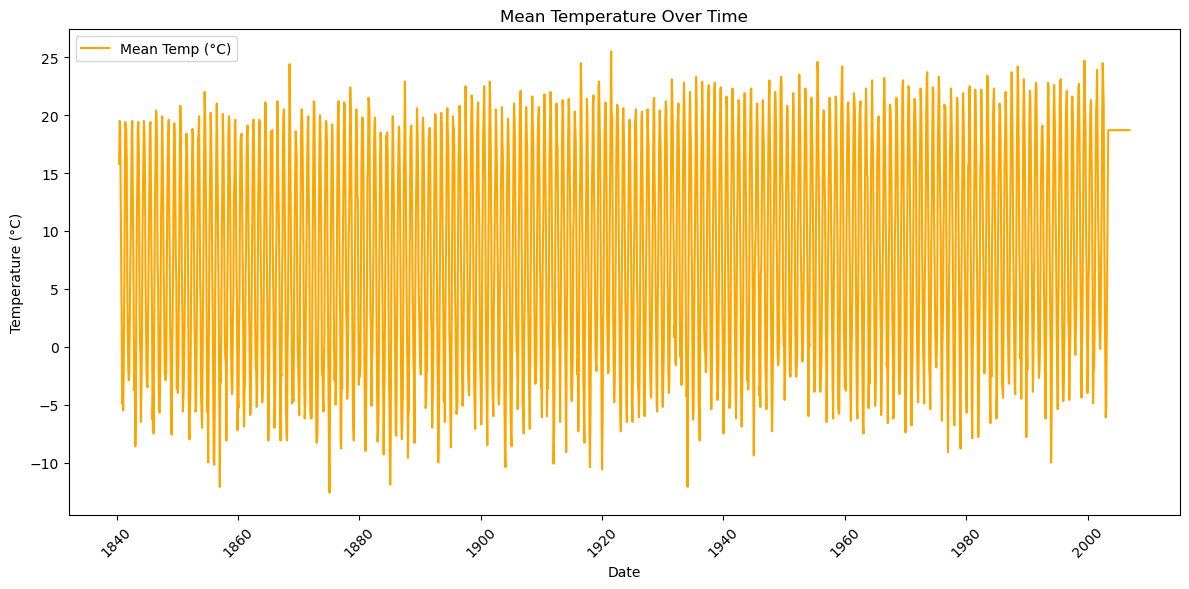

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(weather['Date/Time'], weather['Mean Temp (°C)'], label='Mean Temp (°C)', color='orange')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Mean Temperature Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

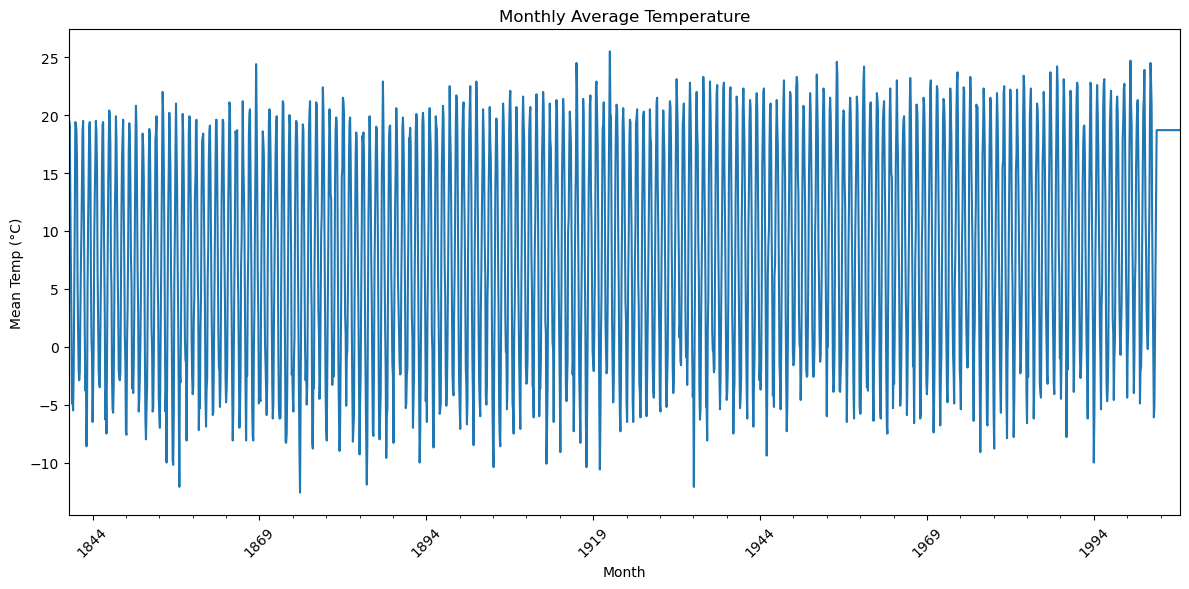

In [43]:
weather['Month'] = weather['Date/Time'].dt.to_period('M')
monthly_avg = weather.groupby('Month')['Mean Temp (°C)'].mean()
monthly_avg.plot(kind='line', figsize=(12, 6), title='Monthly Average Temperature', ylabel='Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

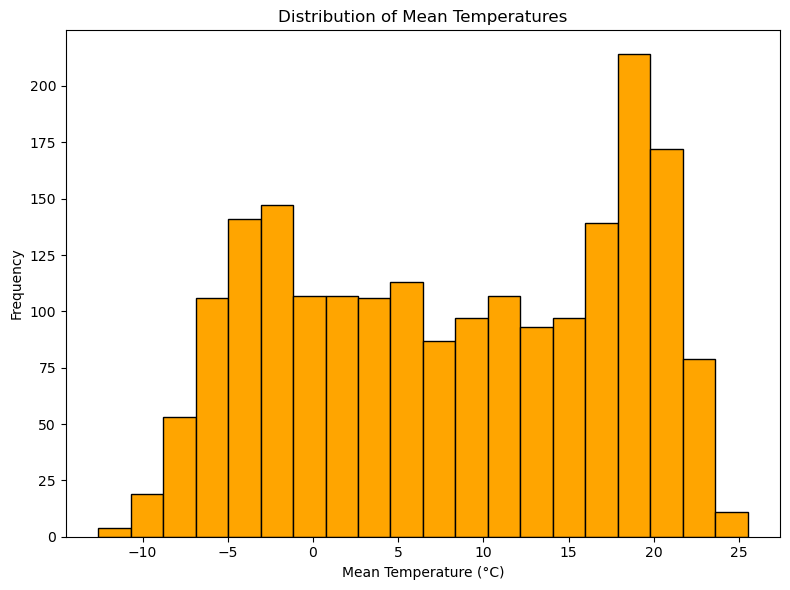

In [45]:
plt.figure(figsize=(8, 6))
plt.hist(weather['Mean Temp (°C)'].dropna(), bins=20, color='orange', edgecolor='black')
plt.title('Distribution of Mean Temperatures')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

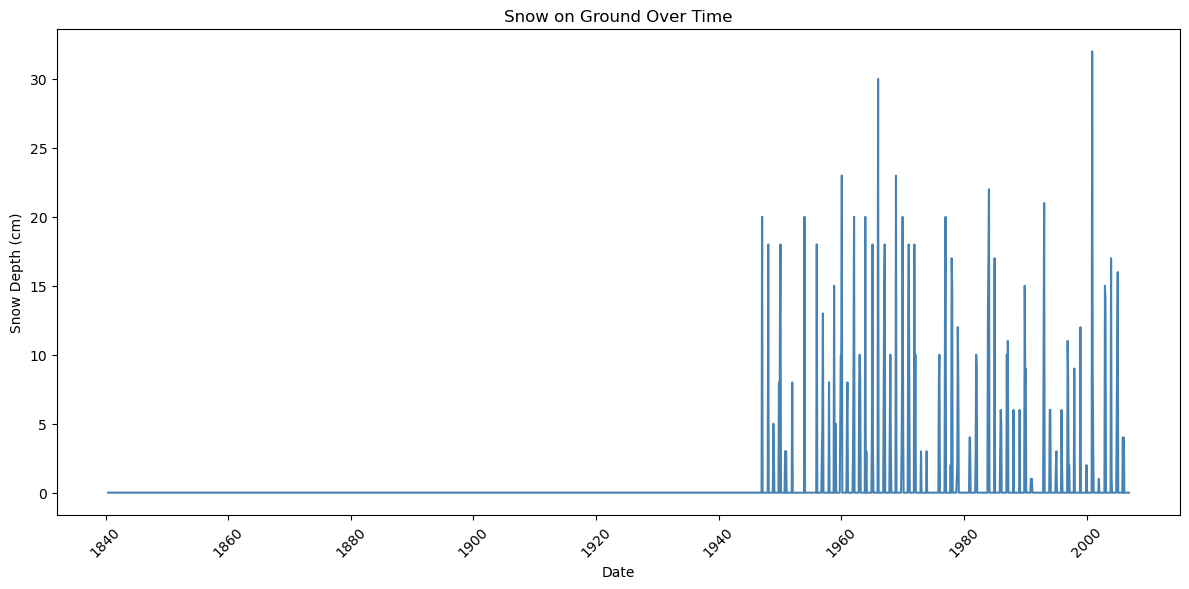

In [47]:
if 'Snow Grnd Last Day (cm)' in weather.columns:
    plt.figure(figsize=(12, 6))
    plt.plot(weather['Date/Time'], weather['Snow Grnd Last Day (cm)'], color='steelblue')
    plt.title('Snow on Ground Over Time')
    plt.xlabel('Date')
    plt.ylabel('Snow Depth (cm)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()